
# 13. Linear Regression: Interpretation, Assumptions, and Limits

Linear regression is one of the most useful statistical models in data science, because it forces us to be explicit about how an outcome varies with measurable inputs. In operational settings it often becomes the first serious baseline for forecasting, prioritization, staffing, pricing, and risk monitoring. Its usefulness comes from clarity: we can inspect coefficients, fitted values, residuals, and uncertainty in a way that is much harder with more opaque models.

That same clarity creates a trap. Because linear regression produces numbers that look precise, analysts can start treating every coefficient as a causal fact and every fitted line as a law of nature. Here we focus on learning the right posture instead. We will use regression as a disciplined approximation to the conditional mean, learn what coefficients communicate and where their interpretation stops, inspect the assumptions that matter, and see how omitted variables, nonlinearity, heteroskedasticity, and influential points can distort the story.



## Learning Objectives

After working through this lecture, you should be able to:

- explain what a linear regression coefficient means as a conditional association;
- fit and interpret an operational regression model in original business units;
- distinguish fitted values, residuals, explanatory fit, and predictive usefulness;
- diagnose visible violations of linearity, constant-variance, and influence assumptions;
- understand why robust standard errors help with inference but do not repair misspecification;
- articulate why omitted variables and bad design block causal interpretation;
- translate a regression model into a cautious decision-support tool with appropriate caution about policy claims.


## Mathematical Core: The Linear Regression Object

Linear regression starts with a conditional-mean model:

$$
\mathbb{E}[Y_i \mid X_i] = X_i^{T}\beta.
$$

The ordinary least squares estimate chooses coefficients that minimize squared residuals:

$$
\widehat{\beta} = \arg\min_{b} \sum_{i=1}^{n} \left(Y_i - X_i^{T}b\right)^2.
$$

A fitted value and residual are

$$
\widehat{Y}_i = X_i^{T}\widehat{\beta},
\qquad
e_i = Y_i - \widehat{Y}_i.
$$

A coefficient is a partial association inside the fitted specification. If `X_j` is numeric, then $\widehat{\beta}_j$ is the fitted change in `Y` for a one-unit change in `X_j`, holding the other included variables fixed. This interpretation depends on the model specification and does not automatically imply causality.

Classical uncertainty calculations use assumptions such as

$$
\mathbb{E}[\varepsilon_i \mid X_i] = 0,
\qquad
\operatorname{Var}(\varepsilon_i \mid X_i) = \sigma^2.
$$

When constant-variance assumptions fail, robust standard errors replace the simple variance formula with a sandwich-style estimate. The point estimate may be the same, but the uncertainty story can change substantially.

In [1]:
# Load the libraries and notebook settings used in the examples below.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import statsmodels.api as sm
import statsmodels.formula.api as smf

from IPython.display import Markdown
from pathlib import Path
import sys

from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.diagnostic import het_breuschpagan

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "notebooks" / "_shared" / "display.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display

sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:.3f}".format
rng = np.random.default_rng(2026)

SEVERITY_ORDER = ["Low", "Medium", "High", "Critical"]


def make_support_regression_data(seed=2026, n_rows=2400):
    """
    Construct the support regression data object used in this lecture.
    
    Parameters:
        seed: Random seed used to make the simulation or resampling reproducible.
        n_rows: Sample size or group size used by the simulation, resampling, or inference step.
    
    Returns:
        A pandas DataFrame of support-ticket records designed for regression interpretation, diagnostics, omitted-variable checks, and prediction scenarios.
    
    Idea:
        Generate a regression setting with interpretable drivers and realistic noise so assumptions, coefficients, and prediction limits can be discussed together.
    """
    rng = np.random.default_rng(seed)

    queue_load = rng.normal(0, 1, n_rows)
    analyst_experience_years = np.clip(rng.normal(5.4, 2.1, n_rows), 0.4, None)
    severity = rng.choice(SEVERITY_ORDER, size=n_rows, p=[0.34, 0.35, 0.22, 0.09])
    severity_score = pd.Series(severity).map({"Low": 1, "Medium": 2, "High": 3, "Critical": 4}).to_numpy()
    priority_account = rng.binomial(1, stats.logistic.cdf(-1.0 + 0.45 * severity_score))
    weekend_intake = rng.binomial(1, 0.18, n_rows)
    prior_tickets = rng.poisson(np.clip(4.5 + 1.2 * np.maximum(queue_load, -0.7) + 1.3 * (severity_score - 1), 0.8, None))

    self_service_share = (
        0.68
        - 0.10 * (severity_score - 1)
        - 0.05 * priority_account
        - 0.04 * np.maximum(queue_load, 0)
        + rng.normal(0, 0.08, n_rows)
    )
    self_service_share = np.clip(self_service_share, 0.02, 0.98)

    latent_complexity = (
        0.55 * (severity_score - 2.0)
        + 0.22 * priority_account
        + 0.12 * prior_tickets
        + rng.normal(0, 0.9, n_rows)
    )

    mean_minutes = (
        22
        + 5.4 * (severity_score - 1)
        + 5.8 * queue_load
        - 1.6 * analyst_experience_years
        + 0.55 * prior_tickets
        - 11.5 * self_service_share
        + 3.6 * priority_account
        + 2.1 * weekend_intake
        + 3.8 * np.maximum(queue_load, 0) ** 2
        + 2.4 * (severity_score - 1) * np.maximum(queue_load, 0)
        + 6.5 * latent_complexity
    )

    noise_sd = 4.5 + 1.4 * severity_score + 1.8 * np.maximum(queue_load, 0)
    resolution_minutes = mean_minutes + rng.normal(0, noise_sd, n_rows)

    outage_flag = np.zeros(n_rows, dtype=int)
    outage_idx = rng.choice(n_rows, size=8, replace=False)
    outage_flag[outage_idx] = 1
    resolution_minutes[outage_idx] += rng.uniform(65, 130, size=len(outage_idx))
    queue_load[outage_idx] += rng.uniform(0.8, 1.6, size=len(outage_idx))
    prior_tickets[outage_idx] += rng.integers(6, 18, size=len(outage_idx))

    resolution_minutes = np.clip(resolution_minutes, 5, None)

    df = pd.DataFrame(
        {
            "case_id": np.arange(1, n_rows + 1),
            "resolution_minutes": resolution_minutes,
            "queue_load": queue_load,
            "analyst_experience_years": analyst_experience_years,
            "prior_tickets": prior_tickets,
            "self_service_share": self_service_share,
            "priority_account": priority_account,
            "weekend_intake": weekend_intake,
            "severity": pd.Categorical(severity, categories=SEVERITY_ORDER, ordered=True),
            "latent_complexity": latent_complexity,
            "outage_flag": outage_flag,
            "true_expected_minutes": mean_minutes,
        }
    )
    return df


def metric_table(y_true, y_pred, label):
    """
    Compute the metric table quantity used in the statistical or decision-science workflow.
    
    Parameters:
        y_true: Observed outcome values.
        y_pred: Predicted outcome values.
        label: Human-readable label attached to the returned summary.
    
    Returns:
        A pandas DataFrame containing regression fit metrics for the named model.
    
    Idea:
        Put model-fit diagnostics on a common scale so the regression discussion stays tied to explanatory value and residual error.
    """
    residual = y_true - y_pred
    return pd.DataFrame(
        {
            "model": [label],
            "r_squared": [1 - (residual.pow(2).sum() / ((y_true - y_true.mean()) ** 2).sum())],
            "rmse": [np.sqrt(np.mean(residual**2))],
            "mae": [np.mean(np.abs(residual))],
            "mean_residual": [residual.mean()],
        }
    )


def coefficient_table(model, label_map=None):
    """
    Compute the coefficient table quantity used in the statistical or decision-science workflow.
    
    Parameters:
        model: Fitted model used to produce estimates, predictions, or uncertainty summaries.
        label_map: Input used by `label_map` in this helper.
    
    Returns:
        A pandas DataFrame of selected regression coefficients, standard errors, p-values, and confidence limits.
    
    Idea:
        Collect regression coefficients on an interpretable scale so effect direction, magnitude, and uncertainty can be read together.
    """
    conf = model.conf_int()
    table = pd.DataFrame(
        {
            "term": model.params.index,
            "estimate": model.params.values,
            "std_error": model.bse,
            "t_value": model.tvalues,
            "p_value": model.pvalues,
            "ci_low": conf[0],
            "ci_high": conf[1],
        }
    )
    if label_map is not None:
        table["term"] = table["term"].map(lambda x: label_map.get(x, x))
    return table


def prediction_table(model, scenarios, label_col="scenario"):
    """
    Compute the prediction table quantity used in the statistical or decision-science workflow.
    
    Parameters:
        model: Fitted model used to produce estimates, predictions, or uncertainty summaries.
        scenarios: Scenario table used to generate paired predictions or decision contrasts.
        label_col: Input used by `label_col` in this helper.
    
    Returns:
        A pandas DataFrame of scenario-level model predictions and intervals for decision interpretation.
    
    Idea:
        Organize predicted outcomes and uncertainty for selected scenarios so model results can be interpreted as decision support.
    """
    preds = model.get_prediction(scenarios).summary_frame(alpha=0.05)
    out = pd.concat([scenarios.reset_index(drop=True), preds.reset_index(drop=True)], axis=1)
    cols = [
        label_col,
        "severity",
        "queue_load",
        "analyst_experience_years",
        "prior_tickets",
        "self_service_share",
        "priority_account",
        "weekend_intake",
        "mean",
        "mean_ci_lower",
        "mean_ci_upper",
        "obs_ci_lower",
        "obs_ci_upper",
    ]
    return out[cols]

## 1. What a Regression Model Is Trying to Do

A linear regression model approximates the conditional mean of an outcome given observed predictors:

$$
\mathbb{E}[Y_i \mid X_i] = \beta_0 + \beta_1 X_{i1} + \cdots + \beta_p X_{ip}.
$$

The key word is *conditional*. A slope is not a universal average difference in the entire population. It is the model's estimate of how the expected outcome changes with one predictor while the other regressors in the specification are held fixed.

That makes linear regression valuable for three reasons:

1. it translates data into interpretable units;
2. it exposes where our assumptions enter the analysis;
3. it gives us a transparent baseline before we reach for more complex models.

### Dataset and Experiment Design

For the rest of the lecture we use a simulated but realistic support-operations dataset. Each row is a support ticket with queue load, severity, channel, analyst experience, weekend status, outage status, and resolution time. The decision context is practical: forecast resolution times, understand which factors are associated with longer cases, and decide when the model is useful for planning versus when it is overreaching.

The experiment fits a sequence of regression specifications to the same operational process. We start with a simple linear model, then inspect residuals, add nonlinear and interaction terms, compare uncertainty estimates, study omitted-variable behavior, and examine influential observations. This structure lets us teach regression as a modeling workflow with diagnostics, assumptions, and interpretation built around the formula.

In [2]:
# Simulate data or resample observations to study variability and uncertainty.
regression_df = make_support_regression_data()

smart_display(regression_df.head())

variable_guide = pd.DataFrame(
    [
        {"variable": "resolution_minutes", "role": "Outcome", "why_it_matters": "Continuous service metric that leadership wants to forecast and stabilize."},
        {"variable": "queue_load", "role": "Operational pressure", "why_it_matters": "Measures how congested the system is relative to a typical day."},
        {"variable": "analyst_experience_years", "role": "Capability proxy", "why_it_matters": "More experienced analysts usually resolve cases faster, but this may also reflect assignment patterns."},
        {"variable": "prior_tickets", "role": "Customer history", "why_it_matters": "Repeated issues often signal more complicated cases or accounts."},
        {"variable": "self_service_share", "role": "Case preparation", "why_it_matters": "Cases that arrive after stronger self-service completion are often easier to finish."},
        {"variable": "priority_account", "role": "Account flag", "why_it_matters": "Priority customers can receive faster routing but may also bring more complex incidents."},
        {"variable": "weekend_intake", "role": "Timing", "why_it_matters": "Weekend intake can shift staffing and handoff patterns."},
        {"variable": "severity", "role": "Categorical driver", "why_it_matters": "Severity is a major structural determinant of workload."},
        {"variable": "latent_complexity", "role": "Unobserved factor", "why_it_matters": "Included only in the simulation so we can study omitted-variable bias later."},
    ]
)
smart_display(variable_guide)

overview = pd.DataFrame(
    {
        "quantity": [
            "Cases in sample",
            "Mean resolution time",
            "Median resolution time",
            "90th percentile resolution time",
            "Share from priority accounts",
            "Share of outage-tagged extreme cases",
        ],
        "value": [
            len(regression_df),
            regression_df["resolution_minutes"].mean(),
            regression_df["resolution_minutes"].median(),
            regression_df["resolution_minutes"].quantile(0.90),
            regression_df["priority_account"].mean(),
            regression_df["outage_flag"].mean(),
        ],
    }
)
smart_display(overview)


,case_id,resolution_minutes,queue_load,analyst_experience_years,prior_tickets,self_service_share,priority_account,weekend_intake,severity,latent_complexity,outage_flag,true_expected_minutes
0,1,30.788,-0.793,9.093,4,0.520,0,0,Medium,2.414,0,20.156
1,2,25.603,0.241,2.730,4,0.541,0,0,Low,0.072,0,15.700
2,3,44.916,-1.896,5.003,7,0.312,0,0,Critical,3.513,0,42.293
3,4,32.279,1.396,4.939,10,0.445,1,0,Low,0.814,0,38.872
4,5,27.761,0.638,3.940,8,0.668,0,0,Low,1.792,0,29.316


,variable,role,why_it_matters
0,resolution_minutes,Outcome,Continuous service metric that leadership wants to forecast and stabilize.
1,queue_load,Operational pressure,Measures how congested the system is relative to a typical day.
2,analyst_experience_years,Capability proxy,"More experienced analysts usually resolve cases faster, but this may also reflect assignment patterns."
3,prior_tickets,Customer history,Repeated issues often signal more complicated cases or accounts.
4,self_service_share,Case preparation,Cases that arrive after stronger self-service completion are often easier to finish.
5,priority_account,Account flag,Priority customers can receive faster routing but may also bring more complex incidents.
6,weekend_intake,Timing,Weekend intake can shift staffing and handoff patterns.
7,severity,Categorical driver,Severity is a major structural determinant of workload.
8,latent_complexity,Unobserved factor,Included only in the simulation so we can study omitted-variable bias later.


,quantity,value
0,Cases in sample,2400.000000
1,Mean resolution time,28.521146
2,Median resolution time,24.511468
3,90th percentile resolution time,56.597283
4,Share from priority accounts,0.502083
5,Share of outage-tagged extreme cases,0.003333


The setup is intentionally imperfect. The outcome is approximately linear in some variables, clearly nonlinear in queue stress, and influenced by an unobserved complexity factor. That is useful for teaching, because real regression work almost never happens in a world where all assumptions are perfectly satisfied.

Notice one especially important design choice. We know the hidden variable only because this is a simulation. In real data, the analyst would not get to inspect the omitted variable directly. That is exactly why regression diagnostics can reveal *symptoms* of a bad model but rarely prove that the specification is fully correct.


## 2. Fit a Baseline Linear Regression and Interpret It Carefully

We begin with a plain operational model:

- continuous predictors for queue load, experience, prior tickets, and self-service completion;
- indicator variables for priority accounts and weekend intake;
- categorical severity effects.

This is the kind of first-pass regression an analyst might actually fit in a business setting after an EDA pass.


In [3]:
# Fit the statistical or machine-learning model used for this comparison.
baseline_formula = (
    "resolution_minutes ~ queue_load + analyst_experience_years + prior_tickets + "
    "self_service_share + priority_account + weekend_intake + C(severity)"
)

baseline_model = smf.ols(baseline_formula, data=regression_df).fit()

baseline_fit = metric_table(regression_df["resolution_minutes"], baseline_model.fittedvalues, "Baseline OLS")
smart_display(baseline_fit)

term_labels = {
    "Intercept": "Intercept",
    "C(severity)[T.Medium]": "Severity: Medium vs Low",
    "C(severity)[T.High]": "Severity: High vs Low",
    "C(severity)[T.Critical]": "Severity: Critical vs Low",
    "queue_load": "Queue load (1-unit increase)",
    "analyst_experience_years": "Analyst experience (years)",
    "prior_tickets": "Prior tickets (count)",
    "self_service_share": "Self-service share (0 to 1)",
    "priority_account": "Priority account (1 vs 0)",
    "weekend_intake": "Weekend intake (1 vs 0)",
}

baseline_coef_table = coefficient_table(baseline_model, term_labels)
smart_display(baseline_coef_table)


,model,r_squared,rmse,mae,mean_residual
0,Baseline OLS,0.709,11.219,8.157,-0.000


,term,estimate,std_error,t_value,p_value,ci_low,ci_high
Intercept,Intercept,21.425,2.090,10.253,0.000,17.328,25.523
C(severity)[T.Medium],Severity: Medium vs Low,7.466,0.643,11.613,0.000,6.206,8.727
C(severity)[T.High],Severity: High vs Low,15.949,0.904,17.652,0.000,14.177,17.721
C(severity)[T.Critical],Severity: Critical vs Low,25.222,1.262,19.979,0.000,22.746,27.697
queue_load,Queue load (1-unit increase),8.725,0.252,34.604,0.000,8.231,9.220
analyst_experience_years,Analyst experience (years),-1.360,0.110,-12.362,0.000,-1.575,-1.144
prior_tickets,Prior tickets (count),1.788,0.091,19.641,0.000,1.610,1.967
self_service_share,Self-service share (0 to 1),-12.951,2.900,-4.466,0.000,-18.638,-7.265
priority_account,Priority account (1 vs 0),3.848,0.487,7.895,0.000,2.892,4.804
weekend_intake,Weekend intake (1 vs 0),1.130,0.588,1.923,0.055,-0.022,2.282



Three interpretation habits matter here.

First, a coefficient is in the units of the outcome. If the slope on `prior_tickets` is positive, the model is saying that otherwise comparable cases with one additional prior ticket are associated with more expected resolution minutes.

Second, the coefficient is *conditional on the rest of the model*. The severity coefficients compare cases at the same queue load, experience, self-service share, and so on.

Third, the coefficient is not automatically causal. If high-priority accounts systematically receive harder cases, the priority-account coefficient mixes routing policy, account type, and latent complexity. Regression gives a conditional association unless the design and assumptions justify a causal interpretation.


In [4]:
# Build a summary table that supports the interpretation in the surrounding notes.
baseline_scenarios = pd.DataFrame(
    [
        {
            "scenario": "Routine medium-severity case",
            "severity": "Medium",
            "queue_load": -0.2,
            "analyst_experience_years": 5.5,
            "prior_tickets": 5,
            "self_service_share": 0.62,
            "priority_account": 0,
            "weekend_intake": 0,
        },
        {
            "scenario": "Critical case during a queue spike",
            "severity": "Critical",
            "queue_load": 1.6,
            "analyst_experience_years": 3.0,
            "prior_tickets": 11,
            "self_service_share": 0.28,
            "priority_account": 1,
            "weekend_intake": 1,
        },
    ]
)
baseline_scenarios["severity"] = pd.Categorical(baseline_scenarios["severity"], categories=SEVERITY_ORDER, ordered=True)

baseline_predictions = prediction_table(baseline_model, baseline_scenarios)
smart_display(baseline_predictions)


,scenario,severity,queue_load,analyst_experience_years,prior_tickets,self_service_share,priority_account,weekend_intake,mean,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,Routine medium-severity case,Medium,-0.200000,5.500000,5,0.620000,0,0,20.579325,19.597403,21.561248,-1.488991,42.647641
1,Critical case during a queue spike,Critical,1.600000,3.000000,11,0.280000,1,1,77.548718,75.644347,79.453088,55.420161,99.677274



These scenario predictions show why managers like regression models. They turn a pile of historical data into expected outcomes for concrete operating situations. But the predictions are only as good as the approximation. If the model misses curvature, unequal variance, or hidden complexity, the fitted values can look reasonable on average while still being misleading in exactly the situations we care about most.



## 3. Regression Assumptions: What They Buy You and What Happens When They Fail

Below is the short version of the core assumptions we care about in ordinary least squares.

| Assumption | Why it matters | Typical symptom when it fails |
| --- | --- | --- |
| Linearity in the chosen predictors | Coefficients summarize the mean pattern well | Residual curves or systematic under/over-prediction |
| Exogeneity or no omitted confounding in the conditional mean | Coefficients target the right conditional relationship | Slopes absorb hidden structure and become biased |
| Constant variance of errors | Usual standard errors and intervals are calibrated | Residual spread grows or shrinks with fitted values |
| Limited influence of single observations | No tiny set of records dominates the fit | High leverage, large Cook's distance |
| Approximate independence of errors | Inference is not overly optimistic | Clustered or serial error structure |
| Approximate normality of residuals | Small-sample t-tests and intervals behave better | Heavy tails or skewness in QQ plots |

Not every assumption has the same job. Normality is mostly about small-sample inference. Exogeneity is about interpretability. Constant variance is about uncertainty calibration. This is why diagnostics should always be tied to the decision we are making, not treated as a checklist for its own sake.


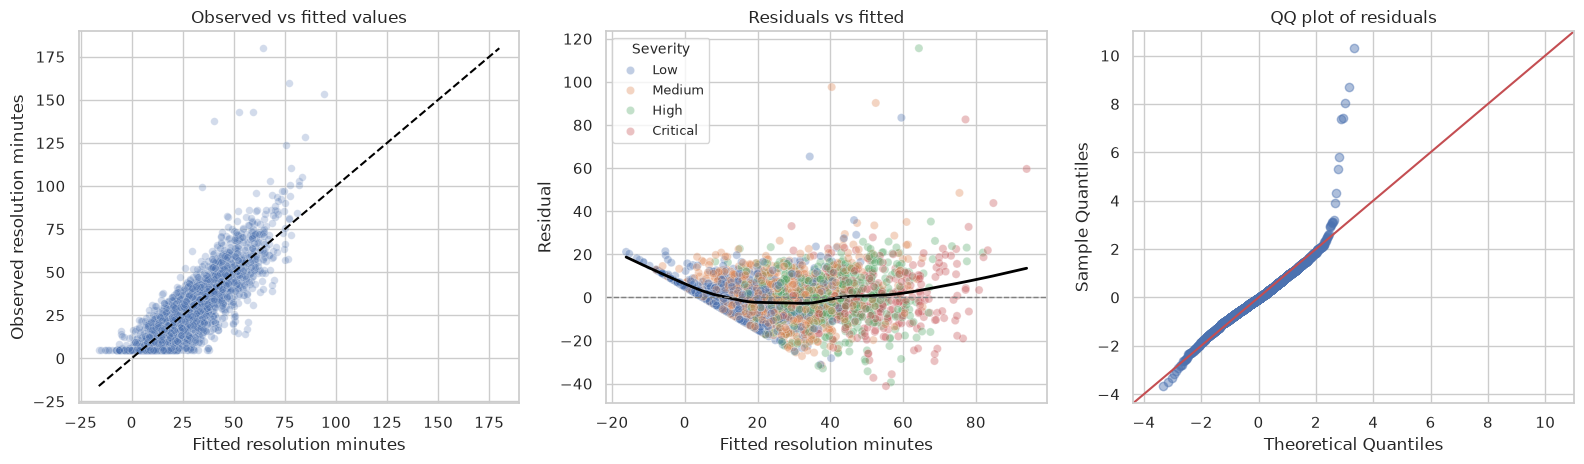

In [5]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.scatterplot(
    x=baseline_model.fittedvalues,
    y=regression_df["resolution_minutes"],
    alpha=0.25,
    s=30,
    ax=axes[0],
)
line_min = min(baseline_model.fittedvalues.min(), regression_df["resolution_minutes"].min())
line_max = max(baseline_model.fittedvalues.max(), regression_df["resolution_minutes"].max())
axes[0].plot([line_min, line_max], [line_min, line_max], color="black", lw=1.5, linestyle="--")
axes[0].set_title("Observed vs fitted values")
axes[0].set_xlabel("Fitted resolution minutes")
axes[0].set_ylabel("Observed resolution minutes")

sns.scatterplot(
    x=baseline_model.fittedvalues,
    y=baseline_model.resid,
    hue=regression_df["severity"],
    alpha=0.35,
    s=35,
    ax=axes[1],
)
lowess_line = lowess(baseline_model.resid, baseline_model.fittedvalues, frac=0.28)
axes[1].plot(lowess_line[:, 0], lowess_line[:, 1], color="black", lw=2)
axes[1].axhline(0, color="gray", linestyle="--", lw=1)
axes[1].set_title("Residuals vs fitted")
axes[1].set_xlabel("Fitted resolution minutes")
axes[1].set_ylabel("Residual")
axes[1].legend(title="Severity", fontsize=9, title_fontsize=10)

sm.qqplot(baseline_model.resid, line="45", fit=True, ax=axes[2], markerfacecolor="#4C72B0", alpha=0.45)
axes[2].set_title("QQ plot of residuals")

plt.tight_layout()
plt.show()



The baseline model already tells us where to worry.

- The fitted-versus-observed plot shows broad tracking, so the model is learning something real.
- The residual plot bends upward in high-stress cases, which hints that the effect of queue load is not purely linear.
- The residual spread is visibly wider for hard cases than for easy ones, which suggests heteroskedasticity.
- The QQ plot usually looks acceptable near the middle and rougher in the tails, which is common when we have a mixture of routine and extreme operational cases.

This is a good example of how diagnostics guide model improvement. They provide evidence about which improvements are likely to matter.



## 4. A Better Specification: Nonlinearity and Interactions

Support operations rarely behave in a perfectly additive linear way. Queue pressure often hurts more when the system is already strained, and the effect of queue stress can differ by severity. To reflect that reality, we add:

- a quadratic term for queue load; and
- an interaction between queue load and severity.

This is still a linear regression model in the parameters. The model is *linear in coefficients*, not necessarily linear in the raw predictors.


,model,r_squared,rmse,mae,mean_residual
0,Baseline OLS,0.709073,11.219257,8.157091,-0.000000
1,Add queue curvature + severity interaction,0.751614,10.366592,7.444361,-0.000000


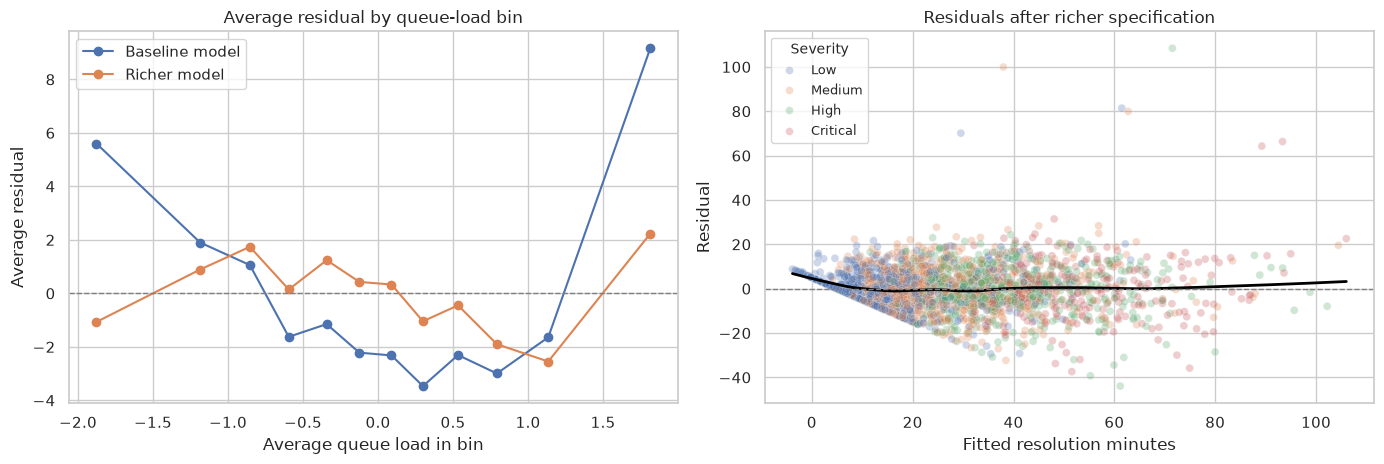

In [6]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
rich_formula = (
    baseline_formula
    + " + I(queue_load ** 2) + queue_load:C(severity)"
)

rich_model = smf.ols(rich_formula, data=regression_df).fit()

model_comparison = pd.concat(
    [
        baseline_fit,
        metric_table(regression_df["resolution_minutes"], rich_model.fittedvalues, "Add queue curvature + severity interaction"),
    ],
    ignore_index=True,
)
smart_display(model_comparison)

residual_compare = regression_df[["queue_load"]].copy()
residual_compare["baseline_resid"] = baseline_model.resid
residual_compare["rich_resid"] = rich_model.resid
residual_compare["queue_bin"] = pd.qcut(residual_compare["queue_load"], q=12, duplicates="drop")

binned_residuals = (
    residual_compare.groupby("queue_bin", observed=True)
    .agg(
        queue_mid=("queue_load", "mean"),
        baseline_mean_resid=("baseline_resid", "mean"),
        richer_mean_resid=("rich_resid", "mean"),
    )
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].plot(binned_residuals["queue_mid"], binned_residuals["baseline_mean_resid"], marker="o", label="Baseline model")
axes[0].plot(binned_residuals["queue_mid"], binned_residuals["richer_mean_resid"], marker="o", label="Richer model")
axes[0].axhline(0, color="gray", linestyle="--", lw=1)
axes[0].set_title("Average residual by queue-load bin")
axes[0].set_xlabel("Average queue load in bin")
axes[0].set_ylabel("Average residual")
axes[0].legend()

sns.scatterplot(
    x=rich_model.fittedvalues,
    y=rich_model.resid,
    hue=regression_df["severity"],
    alpha=0.28,
    s=32,
    ax=axes[1],
)
rich_lowess = lowess(rich_model.resid, rich_model.fittedvalues, frac=0.28)
axes[1].plot(rich_lowess[:, 0], rich_lowess[:, 1], color="black", lw=2)
axes[1].axhline(0, color="gray", linestyle="--", lw=1)
axes[1].set_title("Residuals after richer specification")
axes[1].set_xlabel("Fitted resolution minutes")
axes[1].set_ylabel("Residual")
axes[1].legend(title="Severity", fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.show()



The richer model typically improves RMSE and flattens the residual pattern at high queue load. That is the payoff from taking diagnostics seriously. Adding terms is useful only when the added structure corresponds to a plausible operational mechanism.

This also gives us a useful interpretation lesson. When interactions are present, the meaning of a main-effect slope changes. The queue-load coefficient is no longer a universal queue effect for every severity level. It is the queue effect for the reference severity category, with the interaction terms adjusting that effect for the other categories.



## 5. Heteroskedasticity and Robust Uncertainty

Even after the richer specification, difficult cases usually remain more variable than routine ones. That matters because standard OLS standard errors assume equal error variance.

We will do two things:

1. run a Breusch-Pagan test for heteroskedasticity; and
2. compare conventional standard errors with heteroskedasticity-robust HC3 standard errors.

Robust standard errors help the *uncertainty estimates*. They do **not** repair omitted variables, bad controls, or a badly chosen mean function.


,diagnostic,value
0,Breusch-Pagan LM statistic,136.111
1,Breusch-Pagan LM p-value,0.000
2,Breusch-Pagan F statistic,11.035
3,Breusch-Pagan F p-value,0.000


,term,estimate,classic_se,hc3_se,classic_p,hc3_p
0,Queue load (1-unit increase),6.815,0.392,0.381,0.000,0.000
1,I(queue_load ** 2),2.830,0.150,0.188,0.000,0.000
2,Analyst experience (years),-1.355,0.102,0.112,0.000,0.000
3,Self-service share (0 to 1),-5.986,2.712,3.005,0.027,0.046
4,Priority account (1 vs 0),4.020,0.451,0.439,0.000,0.000
5,Severity: Critical vs Low,27.985,1.180,1.277,0.000,0.000


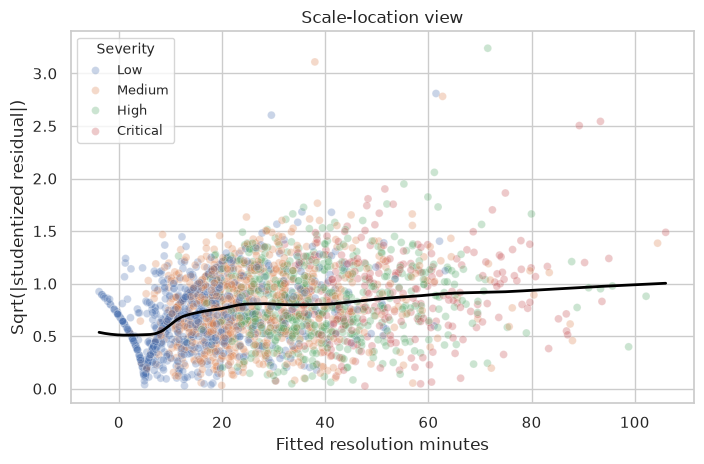

In [7]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
bp_stat, bp_pvalue, f_stat, f_pvalue = het_breuschpagan(rich_model.resid, rich_model.model.exog)

bp_table = pd.DataFrame(
    {
        "diagnostic": ["Breusch-Pagan LM statistic", "Breusch-Pagan LM p-value", "Breusch-Pagan F statistic", "Breusch-Pagan F p-value"],
        "value": [bp_stat, bp_pvalue, f_stat, f_pvalue],
    }
)
smart_display(bp_table)

robust_result = rich_model.get_robustcov_results(cov_type="HC3")
robust_lookup = {
    name: {"hc3_se": robust_result.bse[i], "hc3_p": robust_result.pvalues[i]}
    for i, name in enumerate(rich_model.model.exog_names)
}

terms_to_compare = [
    "queue_load",
    "I(queue_load ** 2)",
    "analyst_experience_years",
    "self_service_share",
    "priority_account",
    "C(severity)[T.Critical]",
]

se_comparison = pd.DataFrame(
    [
        {
            "term": term_labels.get(term, term),
            "estimate": rich_model.params[term],
            "classic_se": rich_model.bse[term],
            "hc3_se": robust_lookup[term]["hc3_se"],
            "classic_p": rich_model.pvalues[term],
            "hc3_p": robust_lookup[term]["hc3_p"],
        }
        for term in terms_to_compare
    ]
)
smart_display(se_comparison)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
abs_resid = np.sqrt(np.abs(rich_model.get_influence().resid_studentized_internal))
sns.scatterplot(
    x=rich_model.fittedvalues,
    y=abs_resid,
    hue=regression_df["severity"],
    alpha=0.30,
    s=32,
    ax=ax,
)
scale_lowess = lowess(abs_resid, rich_model.fittedvalues, frac=0.30)
ax.plot(scale_lowess[:, 0], scale_lowess[:, 1], color="black", lw=2)
ax.set_title("Scale-location view")
ax.set_xlabel("Fitted resolution minutes")
ax.set_ylabel("Sqrt(|studentized residual|)")
ax.legend(title="Severity", fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()



In most runs, the robust standard errors are a bit larger for the stress-sensitive terms. That is exactly what we should expect when variance grows in harder operating conditions.

The interpretation is subtle but important:

- the *coefficient estimates* are unchanged by the robust covariance correction;
- the *standard errors and p-values* become more reliable under heteroskedasticity;
- if the mean model itself is wrong, robust standard errors do not save the substantive interpretation.

This is one of the most common mistakes in applied work: treating robust standard errors as if they made the whole regression robust in every sense. They do not.



## 6. Omitted Variables and the Limits of Interpretation

Because this dataset is simulated, we can do something impossible in real observational practice: fit an "oracle" regression that includes the hidden complexity variable. That lets us see how an omitted predictor can move the coefficients on observed regressors.

This is the right way to think about omitted-variable bias conceptually. The issue is the missing variable itself. The issue is that the missing variable both affects the outcome and is correlated with regressors that remain in the model.


In [8]:
# Fit the statistical or machine-learning model used for this comparison.
oracle_formula = rich_formula + " + latent_complexity"
oracle_model = smf.ols(oracle_formula, data=regression_df).fit()

selected_terms = [
    "queue_load",
    "I(queue_load ** 2)",
    "analyst_experience_years",
    "self_service_share",
    "priority_account",
    "C(severity)[T.High]",
    "C(severity)[T.Critical]",
]

bias_comparison = pd.DataFrame(
    [
        {
            "term": term_labels.get(term, term),
            "observed_model_estimate": rich_model.params[term],
            "oracle_estimate": oracle_model.params[term],
            "difference_due_to_omission": rich_model.params[term] - oracle_model.params[term],
        }
        for term in selected_terms
    ]
)
smart_display(bias_comparison)

latent_corr = (
    regression_df[
        [
            "latent_complexity",
            "queue_load",
            "analyst_experience_years",
            "prior_tickets",
            "self_service_share",
            "priority_account",
        ]
    ]
    .corr()
    .loc[["latent_complexity"], ["queue_load", "analyst_experience_years", "prior_tickets", "self_service_share", "priority_account"]]
    .T
    .reset_index()
    .rename(columns={"index": "observed_variable", "latent_complexity": "correlation_with_hidden_complexity"})
)
smart_display(latent_corr)


,term,observed_model_estimate,oracle_estimate,difference_due_to_omission
0,Queue load (1-unit increase),6.815,6.622,0.193
1,I(queue_load ** 2),2.830,2.828,0.003
2,Analyst experience (years),-1.355,-1.395,0.040
3,Self-service share (0 to 1),-5.986,-5.947,-0.039
4,Priority account (1 vs 0),4.020,2.984,1.036
5,Severity: High vs Low,17.645,12.026,5.619
6,Severity: Critical vs Low,27.985,19.371,8.614


,observed_variable,correlation_with_hidden_complexity
0,queue_load,0.093296
1,analyst_experience_years,-0.013278
2,prior_tickets,0.500637
3,self_service_share,-0.511358
4,priority_account,0.223996



This comparison is the heart of the notebook.

When the hidden complexity variable is omitted, the model still tries to explain the outcome using whatever observed variables are available. If hidden complexity is correlated with severity, prior tickets, or priority-account status, those coefficients partly absorb its effect. This is why a clean-looking regression table can still tell the wrong structural story.

So what can we honestly say from the observational model?

- We can describe conditional associations.
- We can build baseline forecasts.
- We can compare scenario predictions within the support environment represented by the data.
- We cannot automatically claim that changing one regressor would cause the estimated change in resolution time.

That last step requires design logic, design logic and a regression package together.



## 7. Influential Observations Are Diagnostics, Not Garbage Bins

Operational data often contains a small number of unusual but important cases: outages, escalations, legal incidents, or multi-team failures. These cases can exert disproportionate influence on the fitted line.

We should inspect them, but not automatically delete them. Sometimes they are data-entry errors. Other times they are exactly the events leadership most cares about.


,case_id,severity,queue_load,analyst_experience_years,prior_tickets,resolution_minutes,fitted,residual,leverage,studentized_residual,cooks_d,outage_flag
385,386,High,1.577,5.838,16,179.924,71.502,108.422,0.013,10.745,0.103,1
857,858,Critical,2.181,7.271,12,159.691,93.351,66.340,0.027,6.526,0.084,1
1551,1552,Critical,0.400,2.563,26,153.538,89.243,64.295,0.027,6.321,0.078,1
1493,1494,Medium,0.625,10.188,16,137.937,37.984,99.953,0.012,9.863,0.078,1
1113,1114,Low,1.889,1.619,16,142.879,61.473,81.405,0.015,7.993,0.069,1
1202,1203,Medium,2.124,7.897,13,142.682,62.751,79.932,0.012,7.833,0.054,1
951,952,Low,0.152,4.919,15,99.684,29.558,70.125,0.009,6.841,0.031,1
743,744,High,-2.860,7.836,13,5.777,32.364,-26.587,0.031,-2.601,0.015,0


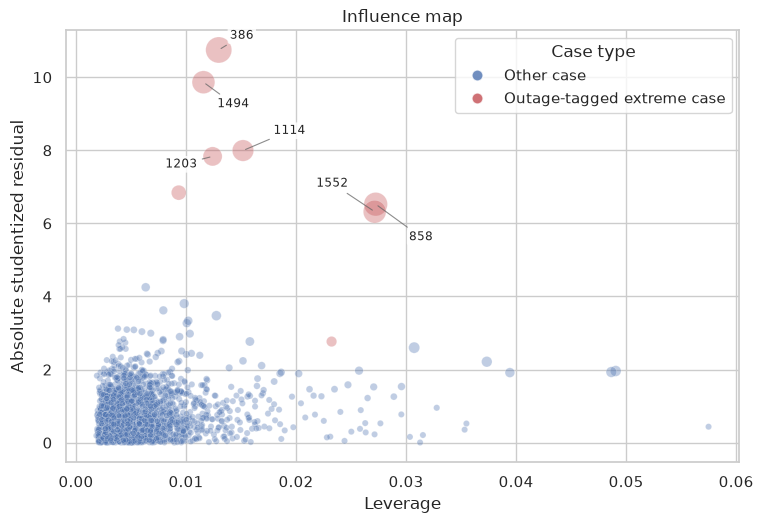

In [9]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
influence = rich_model.get_influence()

diag_df = regression_df.copy()
diag_df["fitted"] = rich_model.fittedvalues
diag_df["residual"] = rich_model.resid
diag_df["leverage"] = influence.hat_matrix_diag
diag_df["studentized_residual"] = influence.resid_studentized_external
diag_df["cooks_d"] = influence.cooks_distance[0]
diag_df["outage_label"] = np.where(diag_df["outage_flag"] == 1, "Outage-tagged extreme case", "Other case")

top_influential = (
    diag_df.sort_values("cooks_d", ascending=False)
    .loc[:, [
        "case_id",
        "severity",
        "queue_load",
        "analyst_experience_years",
        "prior_tickets",
        "resolution_minutes",
        "fitted",
        "residual",
        "leverage",
        "studentized_residual",
        "cooks_d",
        "outage_flag",
    ]]
    .head(8)
)
smart_display(top_influential)

fig, ax = plt.subplots(figsize=(7.8, 5.4))
size = 9000 * np.clip(diag_df["cooks_d"], 0.002, None)
sns.scatterplot(
    data=diag_df,
    x="leverage",
    y=np.abs(diag_df["studentized_residual"]),
    hue="outage_label",
    size=size,
    sizes=(20, 350),
    alpha=0.35,
    palette={"Other case": "#4C72B0", "Outage-tagged extreme case": "#C44E52"},
    legend=False,
    ax=ax,
)
ax.set_title("Influence map")
ax.set_xlabel("Leverage")
ax.set_ylabel("Absolute studentized residual")
legend_handles = [
    Line2D([0], [0], marker="o", color="w", label="Other case", markerfacecolor="#4C72B0", markersize=8, alpha=0.8),
    Line2D([0], [0], marker="o", color="w", label="Outage-tagged extreme case", markerfacecolor="#C44E52", markersize=8, alpha=0.8),
]
ax.legend(handles=legend_handles, title="Case type", loc="upper right", frameon=True)

label_offsets = [(8, 8), (24, -26), (-42, 18), (10, -18), (22, 12), (-34, -8)]
for (x_offset, y_offset), (_, row) in zip(label_offsets, top_influential.head(6).iterrows()):
    ax.annotate(
        str(int(row["case_id"])),
        xy=(row["leverage"], abs(row["studentized_residual"])),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=8.8,
        color="#222222",
        bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": "none", "alpha": 0.82},
        arrowprops={"arrowstyle": "-", "color": "#666666", "lw": 0.8, "alpha": 0.75},
    )

plt.tight_layout()
plt.show()



In many runs, the most influential cases are also outage-tagged cases or critical high-load tickets. That is reassuring in one sense: the model is reacting to genuine extremes from genuine extremes in the data.

But it also exposes a modeling limit. If the organization truly cares about those tail events, a single global mean regression may not be enough. We may need separate incident models, quantile regression, nonlinear models, or explicit escalation rules. Linear regression is often an excellent baseline, but baselines are not the whole system.



## 8. Using Regression as Decision Support Without Overselling It

A mature analyst uses regression in two layers:

1. as a descriptive and forecasting tool for the operating regime represented in the data; and
2. as an input into follow-up design choices, including experimentation, queue policies, and staffing thresholds.

The first layer is a set of scenario forecasts. We ask what the richer model forecasts for several operational scenarios and use those forecasts to define escalation triggers.


In [10]:
# Build a summary table that supports the interpretation in the surrounding notes.
decision_scenarios = pd.DataFrame(
    [
        {
            "scenario": "Balanced weekday queue",
            "severity": "Medium",
            "queue_load": 0.0,
            "analyst_experience_years": 5.5,
            "prior_tickets": 5,
            "self_service_share": 0.60,
            "priority_account": 0,
            "weekend_intake": 0,
        },
        {
            "scenario": "High-load weekday queue",
            "severity": "High",
            "queue_load": 1.2,
            "analyst_experience_years": 5.0,
            "prior_tickets": 8,
            "self_service_share": 0.42,
            "priority_account": 1,
            "weekend_intake": 0,
        },
        {
            "scenario": "Critical weekend incident",
            "severity": "Critical",
            "queue_load": 1.8,
            "analyst_experience_years": 4.0,
            "prior_tickets": 12,
            "self_service_share": 0.20,
            "priority_account": 1,
            "weekend_intake": 1,
        },
    ]
)
decision_scenarios["severity"] = pd.Categorical(decision_scenarios["severity"], categories=SEVERITY_ORDER, ordered=True)

scenario_predictions = prediction_table(rich_model, decision_scenarios)
smart_display(scenario_predictions)

trigger_table = pd.DataFrame(
    [
        {
            "rule": "Expected resolution time above 45 minutes",
            "operational_meaning": "Queue is no longer in routine territory; manager should monitor backlog actively.",
        },
        {
            "rule": "Expected resolution time above 60 minutes",
            "operational_meaning": "Open an escalation channel or surge plan because SLA risk is material.",
        },
        {
            "rule": "Prediction interval remains wide even after richer modeling",
            "operational_meaning": "Treat the regression as an early-warning tool, not as a deterministic promise.",
        },
        {
            "rule": "Coefficient-based routing idea looks attractive",
            "operational_meaning": "Test it experimentally before interpreting the association as a policy effect.",
        },
    ]
)
smart_display(trigger_table)

critical_mean = scenario_predictions.loc[scenario_predictions["scenario"] == "Critical weekend incident", "mean"].iloc[0]
high_load_mean = scenario_predictions.loc[scenario_predictions["scenario"] == "High-load weekday queue", "mean"].iloc[0]

if critical_mean > 60:
    recommendation = (
        "The richer regression should be used as a queue-risk warning model. It predicts that critical incidents under heavy load are well beyond routine handling time, so leadership should treat these periods as escalation states. That is a forecasting recommendation, not proof that any single staffing change would cause the full predicted improvement."
    )
elif high_load_mean > 45:
    recommendation = (
        "The model suggests a meaningful deterioration once queue load rises. Use the regression to trigger earlier monitoring and targeted staffing reviews, then validate specific interventions with stronger design."
    )
else:
    recommendation = (
        "Under these scenarios the regression behaves as a stable baseline forecaster. It is still best used for monitoring and planning, with policy interventions evaluated separately."
    )

smart_display(Markdown(f"**Recommendation.** {recommendation}"))


,scenario,severity,queue_load,analyst_experience_years,prior_tickets,self_service_share,priority_account,weekend_intake,mean,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,Balanced weekday queue,Medium,0.000,5.500,5,0.600,0,0,20.184,19.260,21.109,-0.224,40.593
1,High-load weekday queue,High,1.200,5.000,8,0.420,1,0,57.661,56.189,59.133,37.220,78.102
2,Critical weekend incident,Critical,1.800,4.000,12,0.200,1,1,90.613,87.713,93.513,70.020,111.206


,rule,operational_meaning
0,Expected resolution time above 45 minutes,Queue is no longer in routine territory; manager should monitor backlog actively.
1,Expected resolution time above 60 minutes,Open an escalation channel or surge plan because SLA risk is material.
2,Prediction interval remains wide even after richer modeling,"Treat the regression as an early-warning tool, not as a deterministic promise."
3,Coefficient-based routing idea looks attractive,Test it experimentally before interpreting the association as a policy effect.


**Recommendation.** The richer regression should be used as a queue-risk warning model. It predicts that critical incidents under heavy load are well beyond routine handling time, so leadership should treat these periods as escalation states. That is a forecasting recommendation, not proof that any single staffing change would cause the full predicted improvement.

Read this as an interpretation check for the model output. The coefficient table is only the first layer. The estimated relationship must also be large enough to matter, stable under reasonable specifications, and credible in light of the assumptions behind the regression.

For decision science, the model is useful when it clarifies a comparison that stakeholders can act on. If the recommendation changes under small modeling choices or depends on extrapolating outside the observed support, the report should say that directly.



## Wrap-Up

Linear regression remains foundational because it does several jobs well at once:

- it estimates a transparent conditional mean;
- it gives interpretable units for association;
- it produces fitted values and residuals that invite diagnostic scrutiny;
- it serves as a baseline forecasting model for operational decisions.

But the notebook should also leave you with healthy caution.

- A coefficient is not automatically causal.
- Good fit does not guarantee good specification.
- Robust standard errors do not fix omitted variables.
- Influential observations may be operationally important and worth investigating.
- Decision support should reflect uncertainty, not hide it.

If you remember only one sentence, let it be this: **linear regression is most valuable when we use it as an inspectable approximation, not as a machine for manufacturing certainty.**


## 9. Real-Data Companion: Bike Sharing Regression and Specification Risk

The synthetic regression examples let us see omitted variables, heteroskedasticity, and influence with known structure. The UCI Bike Sharing data add a real regression setting where the structure is visible but not controlled by us. The hourly data record rental counts along with calendar variables, hour of day, season, weather, temperature, humidity, windspeed, and working-day indicators.

The target in this companion is bike-rental demand, usually represented by the hourly count. That count is shaped by time, weather, commuting patterns, leisure patterns, and seasonality. A thin linear model can therefore look interpretable while still missing basic structure in the data-generating process.

The companion compares a deliberately simple specification with a richer one. The richer model is still descriptive. Regression coefficients are conditional on the formula, and formula choice must respect the measurement scale, time structure, and operational setting of the dataset.

For clarity, the unit is an hourly bike-rental record. The outcome is rental count, and the experiment compares regression specifications that do or do not respect time, weather, and seasonality. The lesson is about model interpretation under realistic structure, not about proving causal effects.

Data source: [UCI Bike Sharing Dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset).

,model,r_squared,rmse,warning
0,Thin weather-only linear model,0.251000,156.939000,Misses strong time-of-day and seasonal structure.
1,Richer time/weather specification,0.628000,110.688000,"Better prediction, but still not a causal claim about weather."


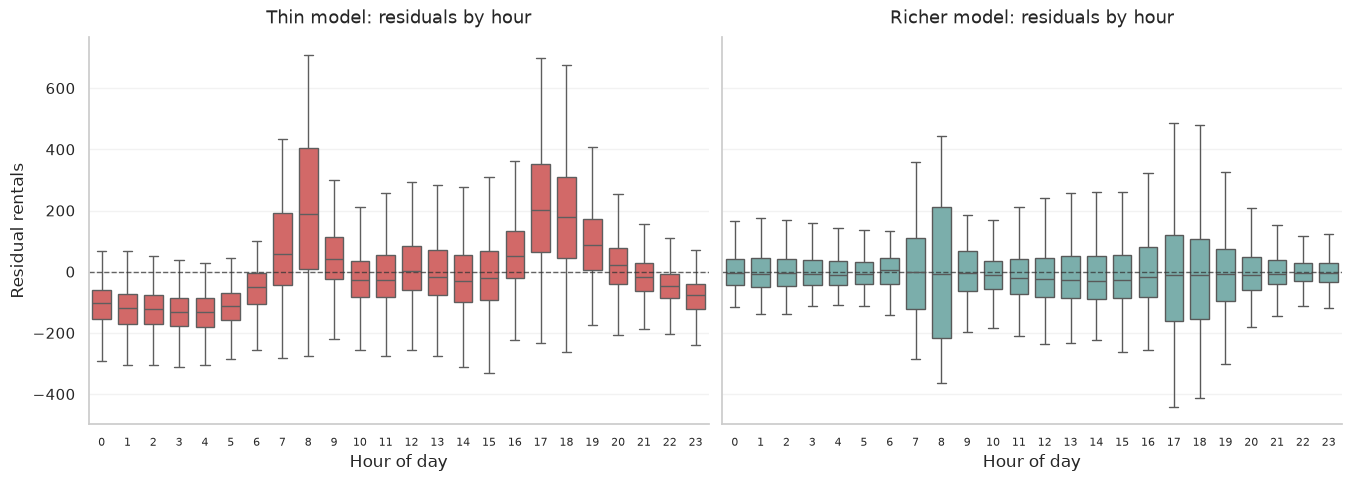

In [11]:
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import load_uci_bike_sharing, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    import statsmodels.formula.api as smf

    bike = load_uci_bike_sharing()
    bike["rush_hour"] = bike["hr"].isin([7, 8, 9, 16, 17, 18]).astype(int)

    thin_model = smf.ols("cnt ~ temp + hum + windspeed", data=bike).fit()
    richer_model = smf.ols(
        "cnt ~ temp + I(temp ** 2) + hum + windspeed + C(hr) + C(weekday) + C(season) + C(weathersit)",
        data=bike,
    ).fit()

    model_comparison = pd.DataFrame(
        [
            {
                "model": "Thin weather-only linear model",
                "r_squared": thin_model.rsquared,
                "rmse": np.sqrt(np.mean(thin_model.resid ** 2)),
                "warning": "Misses strong time-of-day and seasonal structure.",
            },
            {
                "model": "Richer time/weather specification",
                "r_squared": richer_model.rsquared,
                "rmse": np.sqrt(np.mean(richer_model.resid ** 2)),
                "warning": "Better prediction, but still not a causal claim about weather.",
            },
        ]
    )
    smart_display(model_comparison.round(3))

    residual_df = bike.assign(
        thin_resid=thin_model.resid,
        richer_resid=richer_model.resid,
    )

    fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.7), sharey=True, constrained_layout=True)
    boxplot_kws = {"width": 0.72, "linewidth": 1.0, "showfliers": False}

    sns.boxplot(data=residual_df, x="hr", y="thin_resid", ax=axes[0], color="#E45756", **boxplot_kws)
    axes[0].set_title("Thin model: residuals by hour", fontsize=13, pad=10)
    axes[0].set_xlabel("Hour of day")
    axes[0].set_ylabel("Residual rentals")

    sns.boxplot(data=residual_df, x="hr", y="richer_resid", ax=axes[1], color="#72B7B2", **boxplot_kws)
    axes[1].set_title("Richer model: residuals by hour", fontsize=13, pad=10)
    axes[1].set_xlabel("Hour of day")
    axes[1].set_ylabel("")

    for ax in axes:
        ax.axhline(0, color="#333333", linewidth=1.0, linestyle="--", alpha=0.75)
        ax.tick_params(axis="x", labelsize=8)
        ax.grid(axis="y", alpha=0.25)

    sns.despine(fig=fig)
    plt.show()
else:
    optional_data_note(
        "UCI Bike Sharing Dataset",
        "https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset",
        "RUN_REAL_DATA_COMPANION",
    )

If you run this companion, focus on the residual plots. They show a common real-data failure mode: a coefficient table can look precise while the residuals still contain obvious operational structure. The boxplots suppress individual outlier markers so that the median and interquartile range by hour are easier to compare; the outliers still matter, but here the teaching point is the systematic hour-of-day pattern.

Regression is useful for decision support only when the specification is connected to the process that produced the data. The richer model absorbs much more of the hourly structure, but that improvement is still descriptive. It should not be interpreted as a causal claim about weather, time, or demand.


## References

- Shmueli, G. (2010). *To explain or to predict?* Statistical Science, 25(3). [https://doi.org/10.1214/10-STS330](https://doi.org/10.1214/10-STS330)
- White, H. (1980). *A heteroskedasticity-consistent covariance matrix estimator and a direct test for heteroskedasticity.* Econometrica, 48(4), 817-838. [https://doi.org/10.2307/1912934](https://doi.org/10.2307/1912934)
- Breusch, T. S., & Pagan, A. R. (1979). *A simple test for heteroscedasticity and random coefficient variation.* Econometrica, 47(5), 1287-1294. [https://doi.org/10.2307/1911963](https://doi.org/10.2307/1911963)
- Ramsey, J. B. (1969). *Tests for specification errors in classical linear least-squares regression analysis.* Journal of the Royal Statistical Society: Series B, 31(2), 350-371. [https://doi.org/10.1111/j.2517-6161.1969.tb00796.x](https://doi.org/10.1111/j.2517-6161.1969.tb00796.x)
- Cook, R. D. (1977). *Detection of influential observation in linear regression.* Technometrics, 19(1), 15-18. [https://doi.org/10.1080/00401706.1977.10489493](https://doi.org/10.1080/00401706.1977.10489493)
- Anscombe, F. J. (1973). *Graphs in statistical analysis.* The American Statistician, 27(1), 17-21. [https://doi.org/10.1080/00031305.1973.10478966](https://doi.org/10.1080/00031305.1973.10478966)
